# Why We Need Tensors?

Neural Networks take data is some form, like images or text, and produce data in another form, like labels, numbers, or more images or text. Viewed from this angle, deep learning consists of building a system that can transform data from one representation to another. This transformation is driver by finding patterns across many examples that show the input-to-output relationship we want to achieve.

However, both inputs and outputs are actually floating-point numbers. We first convert the input into FP numbers, give it to neural network during the forward path, and interpret the output as a number of a different form. **Tensors are efficient way to store and process this data**.

A DNN typically learns the transformation from one form of data to another in stages. Partially transformed data between each stage can be though of as a sequence of intermediate representations.

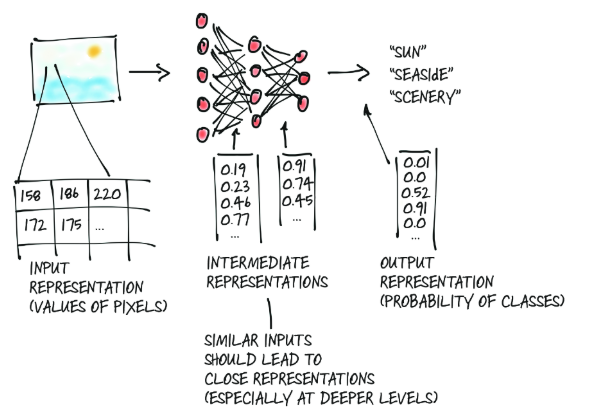


In deep learning tensors refer to the generalization of vectors and matrices to an arbitrary number of dimensions. Another name for the same concept is _multidimensional array_, or _ndarray_ in NumPy. Even more, PyTorch tensor can easily become an NumPy ndarray. It will not make a copy of data, if everything is on CPU. This zero-copy interoperability with NumPy arrays is possible because the storage system works with the Python buffer protocol.

In [8]:
import torch

In [5]:
t1 = torch.tensor([1, 2, 3], device=torch.device("mps"))

In [50]:
# We have to move a tensor from Apple GPU back to RAM (actually the same physical, shared memory!) before converting.  
ndarr1 = t1.cpu().numpy()  # There is also "from_numpy" on tensors
type(ndarr1)

numpy.ndarray

In [87]:
points = torch.ones(3, 4)
points_np = points.numpy()
points_np

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]], dtype=float32)

A tensor’s main superpower — its key feature — is that it can **keep track of the computation graph that created it**.

Tensors are homogeneous (i.e., all elements are of the same data type). So, storing a 1D tensor of 1 million float numbers will require exactly 4 million contiguous bytes, plus a small overhead for the metadata (such as dimensions and numeric type).

In [20]:
import sys

In [19]:
one_mil_ones = torch.ones(1_000_000, dtype=torch.float32)

In [24]:
one_mil_ones.nbytes

4000000

In [35]:
print(one_mil_ones.shape)
print(one_mil_ones.dim())

torch.Size([1000000])
1


In [36]:
d2_t = torch.tensor([[1, 2], [3, 4], [5, 6]])

# The output is another tensor that presents a different view of the same underlying data.
# The new tensor is a 0-D tensor of size 1, referencing the values of the first row in the points tensor. 
print(d2_t[0][1])

print(d2_t.shape)
print(d2_t.dim())

tensor(2)
torch.Size([3, 2])
2


In [31]:
torch.tensor([[1, 2], [3, 4], [5, 6, 4]])  # <--- must be a matrix!

ValueError: expected sequence of length 2 at dim 1 (got 3)

## torch.bfloat16 vs. torch.float16

torch.float16 and torch.bfloat16 are both 16-bit floating-point types, but they trade off range vs precision differently.

A floating-point number is roughly split into:

- sign bit
- exponent bits → control how large or small a value can be
- mantissa / significand bits → control how precise the value is

For these types:

- torch.float16 (IEEE fp16): 1 sign bit, 5 exponent bits, 10 mantissa bits
- torch.bfloat16: 1 sign bit, 8 exponent bits, 7 mantissa bits
- torch.float32: 1 sign bit, 8 exponent bits, 23 mantissa bits

In [47]:
default_points = torch.tensor([0.1, 0.2, 4])
print(default_points.dtype)
double_points = torch.zeros(10, 2).to(torch.double)    # Convert explicitly
short_points = torch.ones(10, 2).to(dtype=torch.short) # Convert explicitly

torch.float32


# Tensor API

Operations on and between tensors are often available as function of `torch` module:

In [61]:
a = torch.ones(3, 2)
a_t = torch.transpose(a, 0, 1)
a.shape, a_t.shape

(torch.Size([3, 2]), torch.Size([2, 3]))

or as method on a tensor:

In [62]:
a = torch.ones(3, 2)
a_t = a.transpose(0, 1)
a.shape, a_t.shape

(torch.Size([3, 2]), torch.Size([2, 3]))

There is no difference between the two forms; they can be used interchangeably.

However, a small number of operations exist only as methods of the Tensor object. They are recognizable from a trailing underscore in their name, like **zero_**, which indicates that the method operates in place by modifying the input instead of creating a new output tensor and returning it.

In [67]:
a = torch.ones(3, 2)
a.zero_()  # In-place replacement
a

tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])

The 1-D underlying storage for any tensor (due to linear nature of physical memory) can be accessed with `.storage()` method:

In [68]:
a_t.storage()

 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6]

Changing the value of a storage changes the content of its referring tensor.

# Tensor Metadata

To index into a storage, tensors rely on a few pieces of information that, together with storage, define them: size, offset, and stride.

**Shape (Size)** is simple. It is a tuple indicating a number of elements across dimension the tensor represents.

In [70]:
a.size()

torch.Size([3, 2])

In [71]:
a.shape

torch.Size([3, 2])

In [72]:
a.size() == a.shape

True

- The **storage offset** is the index in the storage corresponding to the first element in the tensor.
- The **stride** is the number of elements in the storage that need to be skipped over to obtain the next element along each dimension.

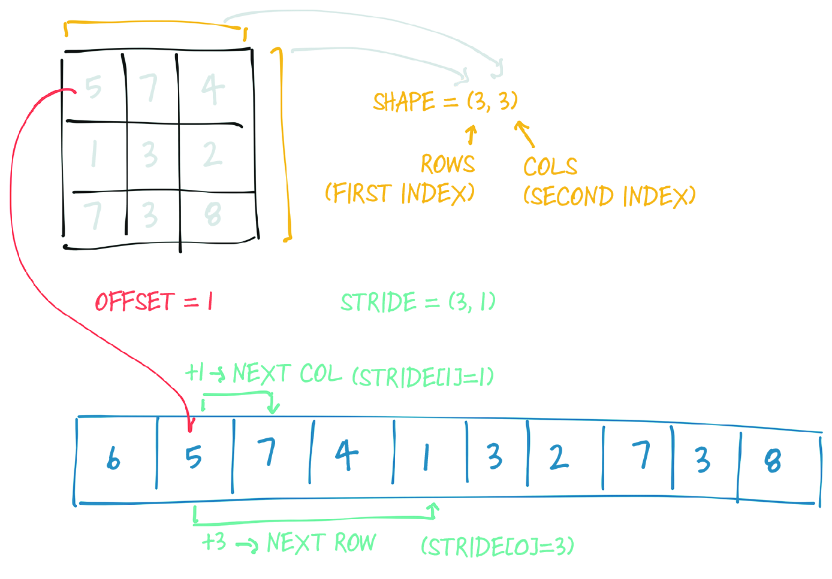


In [73]:
points = torch.tensor([[4.0, 1.0], [5.0, 3.0], [2.0, 1.0]])
second_point = points[1]
second_point.storage_offset()

2

In [78]:
second_point = points[2]
print(second_point.storage_offset())
print(second_point.stride())

4
(1,)


In [77]:
points.stride()  # широкий крок

(2, 1)

Accessing an element `i`, `j` in a 2D tensor results in accessing the `storage_offset + stride[0] * i + stride[1] * j` element in the storage. The offset will usually be zero; if this tensor is a view of a storage created to hold a larger tensor, the offset might be a positive value.

Since all (sub-)tensors are sharing the same storage, we should keep in mind that the are all references with metadata. If we need a full copy, we need to clone explicitly.

In [79]:
point2 = points[1].clone()
point2

tensor([5., 3.])

Not a surprise that transposing is flipping shape and stride! It will also work for for N-dims, but we will need to specify 2 dims we want to use to transpose.

In [82]:
print(points.shape, points.stride())
points_t = points.t()
print(points_t.shape, points_t.stride())

torch.Size([3, 2]) (2, 1)
torch.Size([2, 3]) (1, 2)


Efficient processing of tensors in parallel, especially on GPU, requires them to be contiguous:

In [83]:
print(points.is_contiguous())
print(points_t.is_contiguous())

True
False


We can obtain a new contiguous tensor from a noncontiguous one using the contiguous method. The content of the tensor will be the same, but the stride will change because we are essentially rearranging the values in a new storage:

In [84]:
points_t.storage()

 4.0
 1.0
 5.0
 3.0
 2.0
 1.0
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6]

In [85]:
points_t_cont = points_t.contiguous()
points_t_cont.storage()

 4.0
 5.0
 2.0
 1.0
 3.0
 1.0
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6]

# Dispatching

How the data is stored under the hood is separate from the tensor API.

PyTorch will cause the right computation functions to be called regardless of whether our tensor is on the CPU, GPU, TPU, etc. This is accomplished through a dispatching mechanism, and that mechanism can cater to other tensor types by hooking up the user-facing API to the right backend functions.

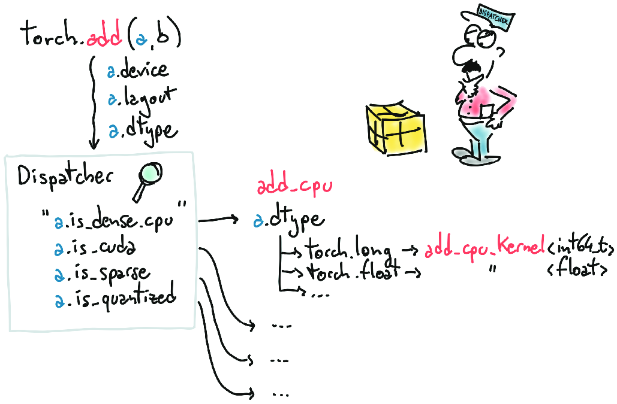


# Serializing Tensors

PyTorch uses pickle to serialize the tensor object, plus dedicated serialization code for the storage.

PyTorch, the file format itself is not interoperable: we can’t read the tensor with software other than PyTorch.

In [96]:
torch.save(points_t, '/tmp/ourpoints.t')

In [97]:
!ls -lh /tmp/ourpoints.t

-rw-r--r--  1 dima  wheel   1.6K Apr  3 18:05 /tmp/ourpoints.t


In [98]:
# loading back
read_points = torch.load('/tmp/ourpoints.t')

In [99]:
read_points

tensor([[4., 5., 2.],
        [1., 3., 1.]])

A common strategy I used previously is storing tensors in [hdf5](https://www.h5py.org/) format, which accepts and returns data in the form of NumPy arrays (free convertion from CPU tensors).

In [101]:
import h5py

In [107]:
import h5py

f = h5py.File('/tmp/ourpoints_t.hdf5', 'w')
dset = f.create_dataset('coords', data=points_t.numpy())

In [109]:
!ls -lh /tmp/ourpoints_t.hdf5

-rw-r--r--  1 dima  wheel    96B Apr  3 18:10 /tmp/ourpoints_t.hdf5


 One of the interesting things in HDF5 is that we can index the dataset while on disk and access only the elements we’re interested in. Let’s suppose we want to load just the last two points in our dataset:

In [112]:
f = h5py.File('/tmp/ourpoints_t.hdf5', 'r')
dset = f['coords']
last_points = dset[-1:]

In [113]:
last_points

array([[1., 3., 1.]], dtype=float32)

The data is not loaded when the file is opened or the dataset is required. Rather, the data stays on disk until we request the second and last rows in the dataset. At that point, h5py accesses those two columns and returns a NumPy array-like object encapsulating that region in that dataset that behaves like a NumPy array and has the same API.

# Images as Tensors

Scalars representing values at individual pixels are often encoded using 8-bit integers (consumer cameras). The most common way to encode colors is RGB where a color is defined by three numbers representing the intensity of red, green, and blue.

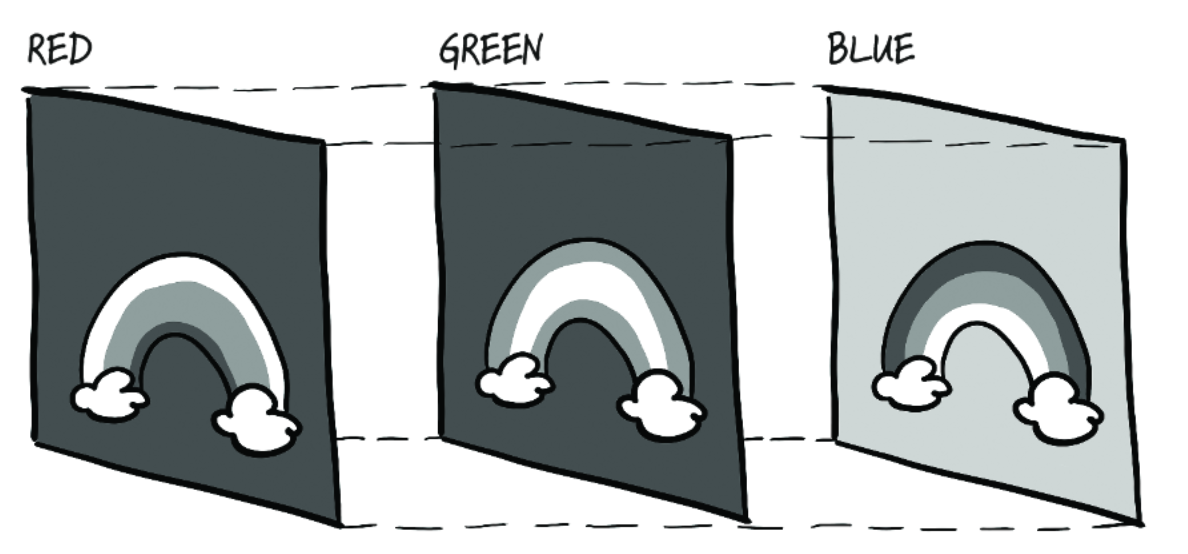


In [2]:
import imageio.v2 as imageio
img_arr = imageio.imread('data/bobby.jpg')
img_arr.shape

(720, 1280, 3)

In [7]:
img_arr

array([[[ 77,  45,  22],
        [ 77,  45,  22],
        [ 78,  46,  21],
        ...,
        [118,  78,  52],
        [117,  77,  51],
        [116,  76,  50]],

       [[ 75,  43,  20],
        [ 76,  44,  21],
        [ 77,  45,  20],
        ...,
        [118,  78,  52],
        [117,  77,  51],
        [116,  76,  50]],

       [[ 74,  39,  17],
        [ 75,  40,  18],
        [ 77,  43,  18],
        ...,
        [117,  80,  51],
        [117,  78,  49],
        [116,  77,  48]],

       ...,

       [[215, 165,  78],
        [216, 166,  79],
        [217, 167,  80],
        ...,
        [174, 121,  51],
        [176, 123,  53],
        [176, 123,  53]],

       [[215, 165,  78],
        [216, 166,  79],
        [217, 167,  80],
        ...,
        [173, 123,  54],
        [174, 124,  55],
        [174, 124,  55]],

       [[215, 165,  78],
        [216, 166,  79],
        [217, 167,  80],
        ...,
        [159, 109,  40],
        [158, 107,  41],
        [158, 107,  41]]

In [6]:
img_arr[0][0]

array([77, 45, 22], dtype=uint8)

At this point, img_arr is a NumPy array-like object with three dimensions: two spatial dimensions, width and height, and a third dimension corresponding to the red, green, and blue channels. Any library that outputs a NumPy array will suffice to obtain a PyTorch tensor.

PyTorch module dealing with images usually expect (channel, height, width). Hence let's **permute** a tensor first (this operation does not make a copy of the tensor data. Instead, out uses the same underlying storage as img and only plays with the size and stride information at the tensor level)

In [10]:
img = torch.from_numpy(img_arr)
out = img.permute(2, 0, 1)
out.shape

torch.Size([3, 720, 1280])

## Data Loading Strategy

We will often need to load a full folder of images, or a single batch. Here is one of the common strategies where we preallocate large enough tensor for batch and load data into it after

In [11]:
import os

In [12]:
png_files = [f for f in os.listdir("data/image-cats/") if f.endswith('.png')]
batch = torch.zeros(len(png_files), 3, 256, 256, dtype=torch.uint8)
batch.shape

torch.Size([3, 3, 256, 256])

In [16]:
for i, f in enumerate(png_files):
    img_arr = imageio.imread(os.path.join("data/image-cats/", f))
    img_t = torch.from_numpy(img_arr)
    img_t = img_t.permute(2, 0, 1)
    img_t = img_t[:3]
    batch[i] = img_t

Since neural networks exhibit the best training performance when the input data ranges roughly from 0 to 1, or from –1 to 1, we need to normalize: 

In [22]:
batch = batch.float()
batch /= 255.0

Or **standardization**: compute the mean and standard deviation of the input data and scale it so that the output has zero mean and unit standard deviation across each channel

In [23]:
n_channels = batch.shape[1]
for c in range(n_channels):
    mean = torch.mean(batch[:, c])
    std = torch.std(batch[:, c])
    batch[:, c] = (batch[:, c] - mean) / std

How to treat columns with continuous, ordinal, and categorical data:

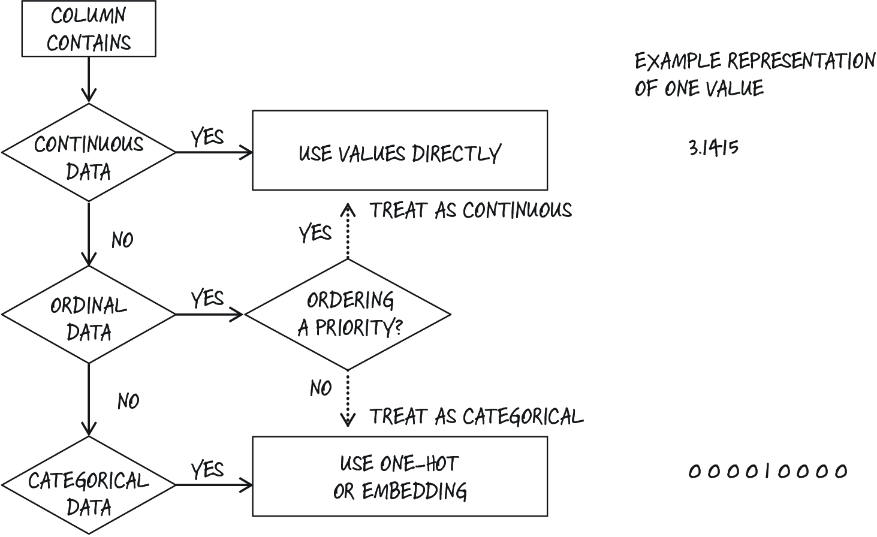

# Working With Time Series

Time series (TS) data emerges in many different applications.

In contrast to data in tables, we can always model TS as an ordered sequence of snapshots.

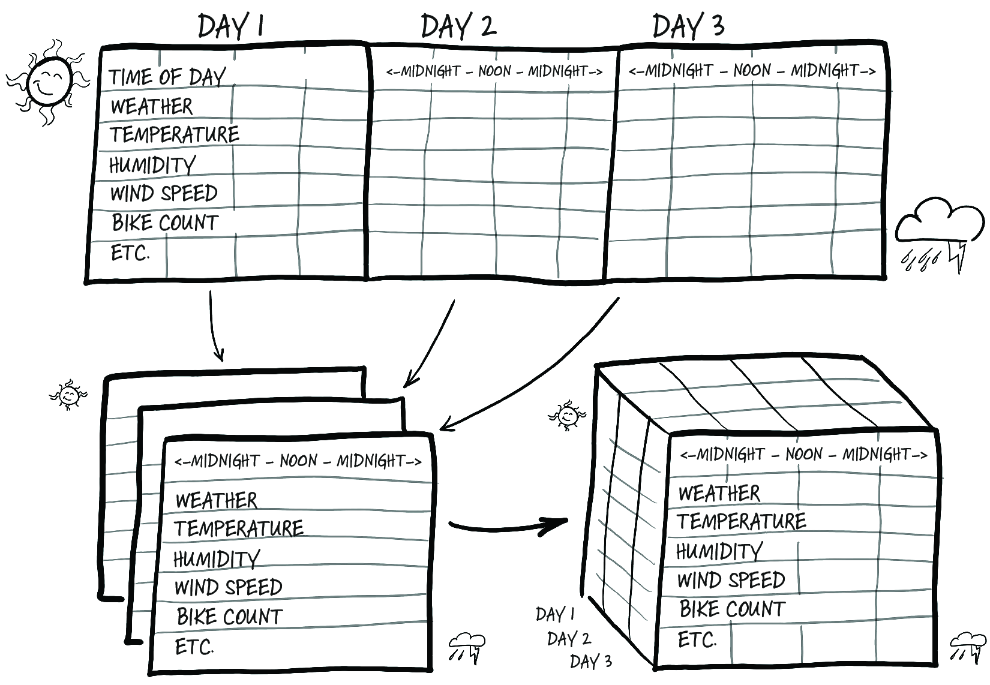


we could treat each row as independent and try to predict the number of circulating bikes based on, say, a particular time of day, regardless of what happened earlier. However, the existence of an ordering gives us the opportunity to exploit causal relationships across time.

# Representing Text

Our goal is to turn text into something a neural network can process - a tensor of numbers. 

There are two particularly intuitive levels at which networks operate on text:

- character level
- word level

In [27]:
!wget http://www.gutenberg.org/files/1342/1342-0.txt
!mv 1342-0.txt data/text_jane_austen.txt

--2026-04-08 17:10:16--  http://www.gutenberg.org/files/1342/1342-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.gutenberg.org/files/1342/1342-0.txt [following]
--2026-04-08 17:10:16--  https://www.gutenberg.org/files/1342/1342-0.txt
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 738046 (721K) [text/plain]
Saving to: ‘1342-0.txt’

1342-0.txt          100%[===================>] 720.75K  1.67MB/s    in 0.4s    

2026-04-08 17:10:25 (1.67 MB/s) - ‘1342-0.txt’ saved [738046/738046]



In [28]:
!head data/text_jane_austen.txt

*** START OF THE PROJECT GUTENBERG EBOOK 1342 ***




                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER



## One-hot-encoding (per character)

In [29]:
with open('data/text_jane_austen.txt') as book_file:
    text = book_file.read()

In [32]:
lines = text.split('\n')

In [35]:
line = lines[200]
line

'own, such as her satire of Mrs. Musgrove’s self-deceiving regrets over'

At this point, we need to parse through the characters in the text and provide a one-hot encoding for each of them. Each character will be represented by a vector of length equal to the number of different characters in the encoding. This vector will contain all 0s, except for a 1 at the index corresponding to the location of the character in the encoding.

In [36]:
# total number of one-hot-encoded characters for the whole line
letter_t = torch.zeros(len(line), 128)
letter_t.shape
# letter_t holds a one-hot-encoded character per row.

torch.Size([70, 128])

In [40]:
for i, letter in enumerate(line.lower().strip()):
    letter_index = ord(letter) if ord(letter) < 128 else 0
    letter_t[i][letter_index] = 1
print(letter_t)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


It is trivial to repeat the same but with `punctuation = '.,;:"!?”“_-'`. The only question is a vocab size.

## Text Embeddings

In [1]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("BAAI/bge-m3")

sentences = [
    "That is a happy person",
    "That is a happy dog",
    "That is a very happy person",
    "Today is a sunny day"
]
embeddings = model.encode(sentences)

similarities = model.similarity(embeddings, embeddings)
print(similarities.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

torch.Size([4, 4])


In [2]:
similarities

tensor([[1.0000, 0.8589, 0.9666, 0.7510],
        [0.8589, 1.0000, 0.8252, 0.6802],
        [0.9666, 0.8252, 1.0000, 0.7296],
        [0.7510, 0.6802, 0.7296, 1.0000]])